# CROCUS Network Dashboard

Real-time sensor status across all CROCUS Sage/Waggle nodes.
Run this notebook at the start of each work session to check network health
before querying data.

- Sage Data Client: https://github.com/sagecontinuum/sage-data-client
- CROCUS Instrument Cookbooks: https://crocus-urban.github.io/instrument-cookbooks/
- Sage Continuum Portal: https://portal.sagecontinuum.org/nodes/project/sage

In [6]:
# Standard library
import datetime as dt
import ssl

# Third party
import matplotlib.pyplot as plt
import pandas as pd
import sage_data_client

# Local
import importlib
import crocus_sites
importlib.reload(crocus_sites)
import sage_utils
importlib.reload(sage_utils)
import coverage_utils
importlib.reload(coverage_utils)

from crocus_sites import (
    ALL_SITES,
    ATMOS, BIG, CCICS, CSU,
    HUM, NEIU, NU, SHEDD, UIC,
)
from sage_utils import last_n_hours
from coverage_utils import (
    check_network_status, plot_network_status,
    plot_node_status, CANARY_VARIABLES, SENSOR_FLAGS,
)

ssl._create_default_https_context = ssl._create_unverified_context

## Network Status Grid

Current sensor status across all CROCUS sites. Each cell shows whether the
sensor reported valid non-zero data within the lookback window.

- **Green** — reporting
- **Red** — not reporting
- **Gray** — sensor not configured at this site

Continuous sensors (WXT, AQT, BME, sap flow, MFR) use a 6-hour lookback.
RG-15 uses 24 hours since it only reports during rain events.


Checking network status...
  Checking ATMOS (W0A4)... done
  Checking BIG (W0A0)... done
  Checking CCICS (W08B)... done
  Checking CSU (W08E)... done
  Checking HUM (W0A1)... done
  Checking NEIU (W08D)... done
  Checking NU (W099)... done
  Checking SHEDD (W09E)... done
  Checking UIC (W096)... done


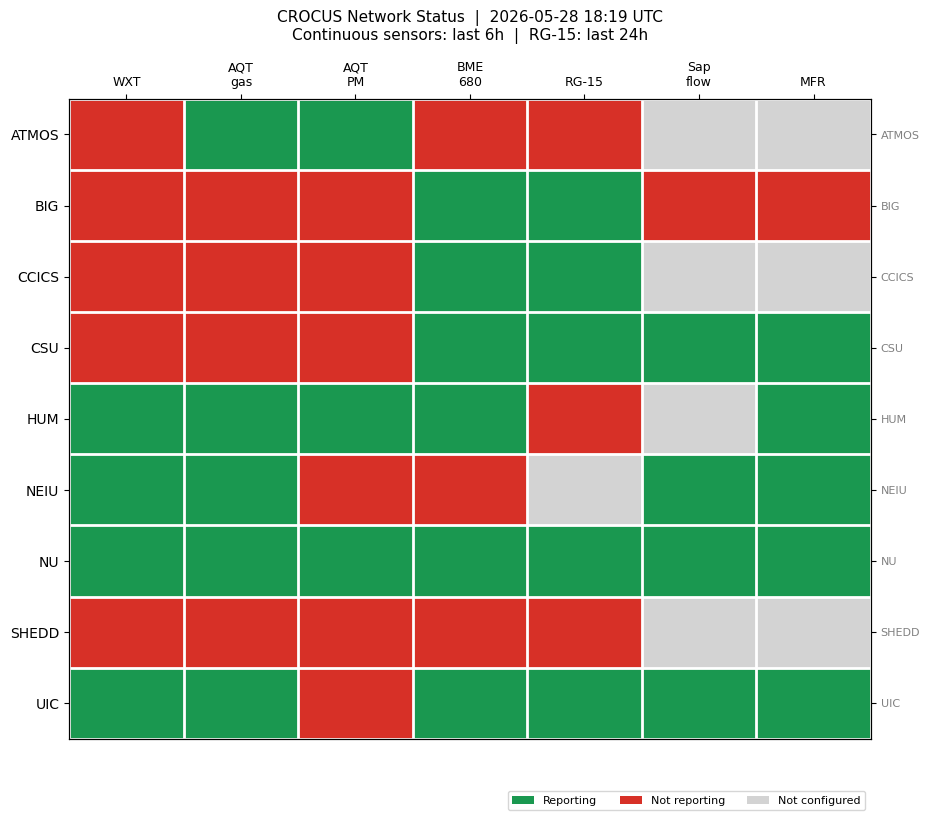

In [7]:
print("Checking network status...")
status = check_network_status(ALL_SITES, hours=6, rg15_hours=24)
plot_network_status(status, hours=6, rg15_hours=24)


## Node App History

Recreates the Sage portal App History visualization — time on x-axis,
one row per plugin, bar height showing record count per time bin.
Change `SITE` to inspect any node.


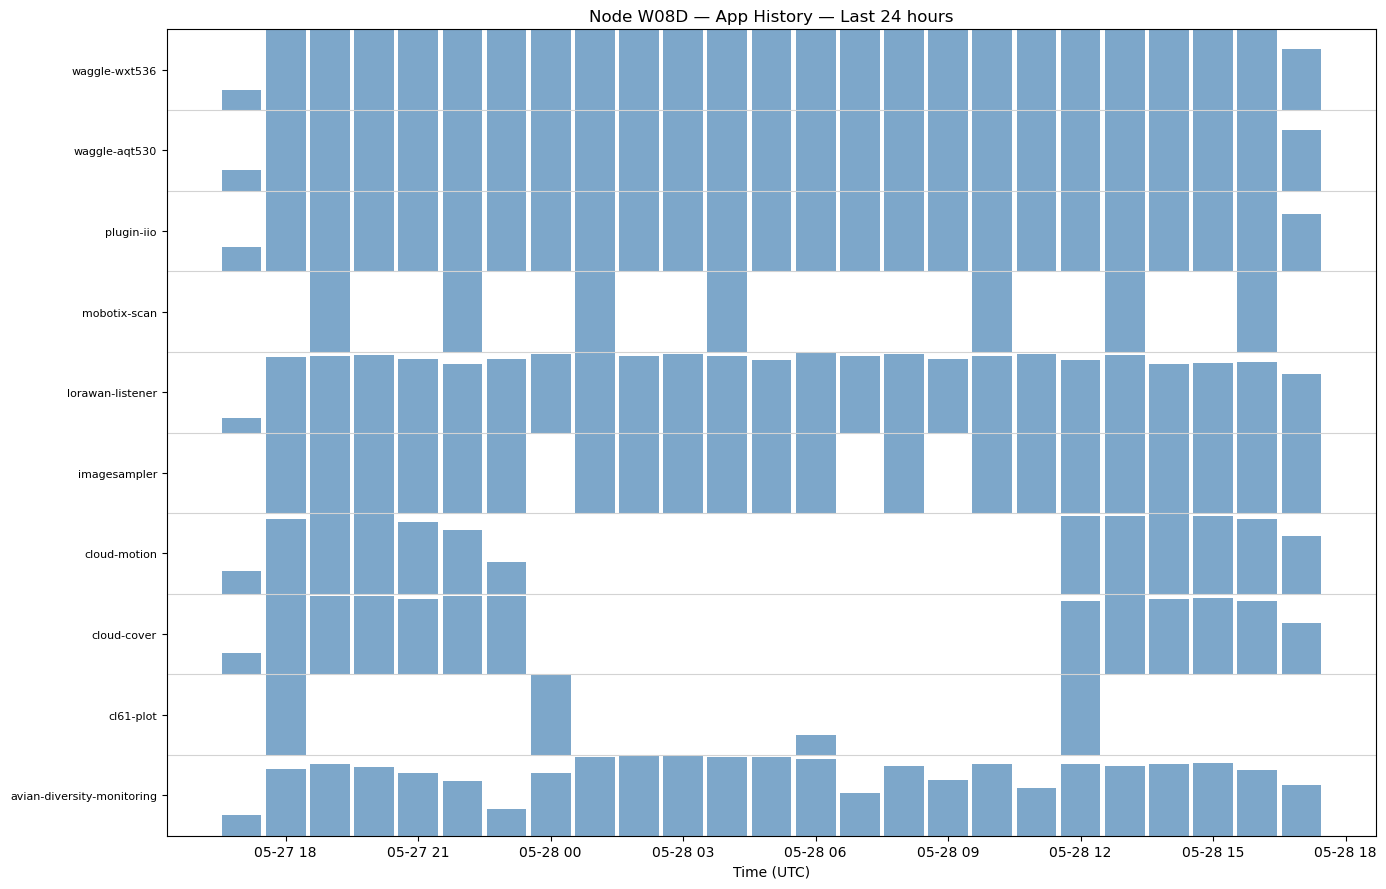

In [3]:
SITE = NEIU
plot_node_status(SITE.vsn, hours=24)
